In [1]:
# conda actovate meteor
# rm -r venv              
# make first-venv
# make clean
# make virtual-environment
# source venv/bin/activate

import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from dataclasses import asdict
import warnings
from pandas.errors import SettingWithCopyWarning
from functools import partial
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings("ignore", message=".*not in pamset.*")

from meteor import MeteorPatternScaling, meteor_plot_utils
from meteor import prpatt
from meteor import Cmip6MeteorDataGetter
from meteor import scm_forcer_engine
from ciceroscm import CICEROSCM
from ciceroscm import input_handler

from meteor.prpatt import global_mean
from meteor.prpatt import recon

import cartopy.crs as ccrs
import cartopy as cart
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.gridspec import GridSpec
from scipy.interpolate import griddata
import matplotlib.ticker as mticker
from scipy.stats import pearsonr


In [2]:
## NBVAL_IGNORE_OUTPUT
#sys.path.insert(0,os.path.join(os.getcwd(), '../'))
#module_path = os.path.abspath(os.path.join('../src'))
#if module_path not in sys.path:
#    sys.path.append(module_path)

#cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

In [3]:
savecache=0

cachedir = os.path.join(os.getcwd(), "cache")
if not os.path.exists(cachedir):
        os.makedirs(cachedir)
        
figdir = os.path.join(os.getcwd(), "figures")
if not os.path.exists(figdir):
        os.makedirs(figdir)

cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Data preparations

### Getting some data that can be used by the forcer engine and ciceroscm

SSP245 for aerorol residual from abrupt-4xCO2

In [4]:
%%capture
ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

#For predictions: 
conc_data = input_handler.read_inputfile(os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt"))
em_data = ih.read_emissions(os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt"))

standard SSP scenarios

In [5]:
scenarios = [ "ssp126", "ssp245", "ssp370", "ssp585"]

In [6]:
%%capture
#For predictions: read in SSP concentrations and emissions
#scenarios = ["ssp126","ssp245","ssp370","ssp585"]

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_fwd=[]
em_data_fwd=[]
for i,s in enumerate(scenarios):
    conc_data_fwd.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_fwd.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

SSP534-over

In [7]:
%%capture
#For predictions: read in SSP concentrations and emissions

ih = input_handler.InputHandler({})
# NBVAL_IGNORE_OUTPUT

conc_data_ssp534=[]
em_data_ssp534=[]
for i,s in enumerate(['ssp534-over']):
    conc_data_ssp534.append(input_handler.read_inputfile(os.path.join(cscm_data_dir, s+"_conc_RCMIP.txt")))
    em_data_ssp534.append(ih.read_emissions(os.path.join(cscm_data_dir, s+"_em_RCMIP.txt")))

### Getting data for standard scenarios

Getting CMIP6 data from the zarrstore for tas

In [8]:
flds = ["tas","pr"]
data_getter = Cmip6MeteorDataGetter(exps=["piControl", "abrupt-4xCO2", "historical", "ssp126", "ssp245", "ssp370", "ssp585"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP','CMIP', 'ScenarioMIP', 'ScenarioMIP','ScenarioMIP', 'ScenarioMIP'])

#for property, value in vars(data_getter).items():
#    print(property)

In [9]:
models = data_getter.models
len(models)

35

Create training data dictionary for all selected models (may run for a while) - and save locally in 'cache' (cachedir) due to data memory requirements

In [10]:
if savecache:
    #training_data_dict = {}
    for nm,mname in enumerate(models):
        print(nm, mname)

        # create model-specific training data
        #training_data_dict[mname] = {
        training_data = {
            "base": data_getter.make_meteor_training_data("base", mname),
            "co2x4": data_getter.make_meteor_training_data("co2x4", mname),
            "sulxanom": data_getter.make_meteor_training_data_composite(["historical", "ssp245"], mname),
        }

        for s in scenarios:
                training_data[s]=data_getter.make_meteor_training_data_composite(
                        ["historical", s], mname
                    )

        # save data locally (cache) to avoid running this cell again and again when accessing data
        for k in training_data:
            training_data[k].to_netcdf(os.path.join(cachedir, f"{mname}_{k}_training_data.nc"))

Load locally saved training data

In [11]:
# remove problematic models when creating the pattern
if 'IITM-ESM' in models: models.pop(models.index('IITM-ESM'))  # drop because bad data
if 'IPSL-CM6A-LR' in models: models.pop(models.index('IPSL-CM6A-LR'))  # drop because of data issue
if 'TaiESM1' in models: models.pop(models.index('TaiESM1'))  # drop because of data issue
if 'EC-Earth3' in models: models.pop(models.index('EC-Earth3'))  # drop because of data issue in pr
#if 'MRI-ESM2-0' in models: models.pop(models.index('MRI-ESM2-0'))

In [12]:
training_data_dict={}
for nm,mname in enumerate(models):
    #print(nm,mname)

    training_data_dict[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
        "ssp126": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp126_training_data.nc")),
        "ssp245": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp245_training_data.nc")),
        "ssp370": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp370_training_data.nc")),
        "ssp585": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp585_training_data.nc")),
    }

### Getting data for SSP534-over

In [13]:
data_getter_ssp534 = Cmip6MeteorDataGetter(exps=["piControl", "historical", "ssp534-over"], 
                                    flds = flds, 
                                    dbe=['CMIP','CMIP', 'ScenarioMIP'])

models_ssp534 = data_getter_ssp534.models
len(models_ssp534)

12

In [14]:
# save data to cache (if indicated)
# may need to read in 'base' (piControl) experiemnt data if not done with standard SSPs (or if there is a model missing)
if savecache:
    for nm,mname in enumerate(models_ssp534):
        print(nm, mname)

        # create model-specific training data
        training_data = {
            #"base": data_getter_ssp534.make_meteor_training_data("base", mname),
            "ssp534-over": data_getter_ssp534.make_meteor_training_data_composite(["historical", "ssp534-over"], mname),
        }

        # save data locally (cache) to avoid running this cell again and again when accessing data
        for k in training_data:
            training_data[k].to_netcdf(os.path.join(cachedir, f"{mname}_{k}_training_data.nc"))

In [15]:
if 'EC-Earth3' in models_ssp534: models_ssp534.pop(models_ssp534.index('EC-Earth3'))  # drop because of data issue in pr
if 'IPSL-CM6A-LR' in models_ssp534: models_ssp534.pop(models_ssp534.index('IPSL-CM6A-LR'))  # drop because of data issue


In [16]:
# load locally saved training data
training_data_dict_ssp534={}
for nm,mname in enumerate(models_ssp534):
    #print(nm,mname)

    training_data_dict_ssp534[mname] = {
        "base": xr.open_dataset(os.path.join(cachedir, f"{mname}_base_training_data.nc")),
        "co2x4": xr.open_dataset(os.path.join(cachedir, f"{mname}_co2x4_training_data.nc")),
        "sulxanom": xr.open_dataset(os.path.join(cachedir, f"{mname}_sulxanom_training_data.nc")),
        "ssp534-over": xr.open_dataset(os.path.join(cachedir, f"{mname}_ssp534-over_training_data.nc")),
    }

# GHG patterns

Create GHG modes and patterns for all selected models

In [17]:
%%capture

CMIP_ghg_pattern_dict = {}
for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    CMIP_ghg_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data_dict[mname][key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )


In [18]:
t1_ghg = np.zeros([len(flds),len(models)])
t2_ghg = np.zeros([len(flds),len(models)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        t1_ghg[nv,nm] = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['outp']['t0'].value
        t2_ghg[nv,nm] = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['outp']['t1'].value

Plot single GHG model responses (tas + pr)

In [19]:
%%capture

vmins = [-3,-15]
vmaxs = [3,15]
cmaps = ["RdBu_r","BrBG"]

# prepare figure canvas
fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 3, figure=fig)

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):

        # create figure row by row
        sub = fig.add_subplot(gs[nm, 0])
        sub.set_xlabel("Years")
        sub.set_ylabel("$\Delta$"+var)
        sub.plot(global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :]), color="gray", label="Original data")
        sub.plot(global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])), color="tab:orange", label="Reconstruction")
        sub.legend(frameon=False)
        sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")

        sub = fig.add_subplot(gs[nm, 1])  #,projection=ccrs.PlateCarree())   #sub.coastlines()
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat, 
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])   # ,transform=cart.crs.PlateCarree()

        sub = fig.add_subplot(gs[nm, 2])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])
        
    plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_"+var+".jpg"), bbox_inches='tight')

GHG multi-model composite

In [20]:
### global mean timeseries
CMIP_GHG_gm_response_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
CMIP_GHG_gm_response_recon_co2x4 = np.zeros([len(flds),len(models),100]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        CMIP_GHG_gm_response_co2x4[nv,nm,:] = global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :])
        CMIP_GHG_gm_response_recon_co2x4[nv,nm,:] = global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full']))

In [21]:
# interpolate gridded data to common grid

target_model_grid = 'ACCESS-CM2'

# Define (new) common grid
common_lons = CMIP_ghg_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lon  # Adjust the number of points as needed
common_lats = CMIP_ghg_pattern_dict[target_model_grid].pattern_dict['co2x4']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Interpolate to native grid and data
common_grid_ghg_data_T1 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_ghg_data_T2 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        native_data_T1 = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :]
        native_data_T2 = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][1, :, :]
        native_lons = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lon
        native_lats = CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]["pattern_full"]["v"][0, :, :].lat
        native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
        # Interpolate
        common_grid_ghg_data_T1[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T1).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')
        common_grid_ghg_data_T2[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T2).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')

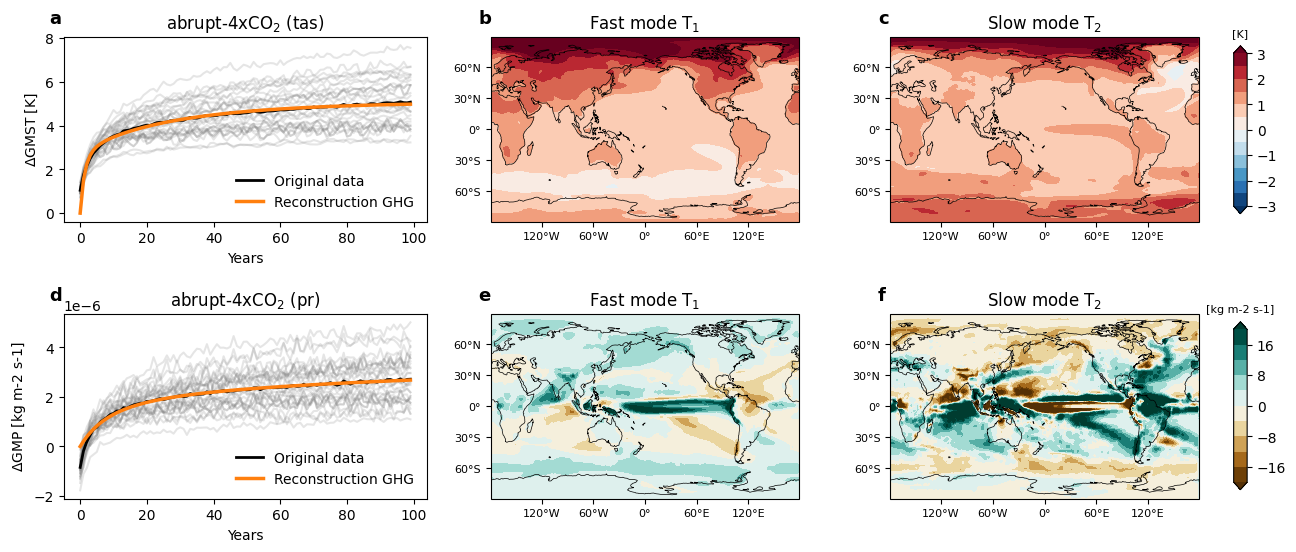

In [22]:
levels = [np.arange(-3,3.1,0.5), np.arange(-20,21,4)]
units = ["[K]","[kg m-2 s-1]"]
titles = ["$\Delta$GMST [K]", "$\Delta$GMP [kg m-2 s-1]"]
labels = (["a","b","c"],
          ["d","e","f"])
cmaps = ["RdBu_r","BrBG"]

fig = plt.figure(figsize=(15,6))
gs = GridSpec(2, 3, figure=fig)

for nv,var in enumerate(flds):

    sub = fig.add_subplot(gs[nv, 0])
    sub.set_title("abrupt-4xCO$_2$ ("+var+")")
    sub.set_xlabel("Years")
    sub.set_ylabel(titles[nv])
    #sub.set_xlim(0,100)
    #sub.set_ylim(0,8)
    for nm,mname in enumerate(models):
        sub.plot(global_mean(CMIP_ghg_pattern_dict[mname].dacanom[var][CMIP_ghg_pattern_dict[mname].exp_list.index('co2x4'), :100, :, :]), color="gray", alpha=0.2)
        #sub.plot(global_mean(recon(CMIP_ghg_pattern_dict[mname].pattern_dict['co2x4'][var]['pattern_full'])), color="gray", alpha=0.3)
    sub.plot(np.nanmean(CMIP_GHG_gm_response_co2x4[nv,:,:],0), color="black", lw=2, label="Original data")
    sub.plot(np.nanmean(CMIP_GHG_gm_response_recon_co2x4[nv,:,:],0), color="tab:orange", lw=2.5, label="Reconstruction GHG")
    sub.legend(frameon=False)
    sub.annotate(labels[nv][0], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    sub.set_title("Fast mode T$_1$")
    cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T1[nv,:,:,:],0), cmap=cmaps[nv], levels=levels[nv], extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.2)
    sub.annotate(labels[nv][1], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    sub.set_title("Slow mode T$_2$")
    cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_ghg_data_T2[nv,:,:,:],0), cmap=cmaps[nv], levels=levels[nv], extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.2)
    sub.annotate(labels[nv][2], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    # external colorbar
    if var == "tas":
        cbar = fig.add_axes([0.905, 0.585, 0.009, 0.28])
    if var == "pr":
        cbar = fig.add_axes([0.905, 0.125, 0.009, 0.28])
    fig.colorbar(cont, cax=cbar,orientation='vertical')
    cbar.set_title(units[nv], size=8, pad=12, ha="center")

fig.subplots_adjust(wspace=0.1, hspace=0.5)
plt.savefig(os.path.join(figdir, "CMIP_GHG_pattern_composite.pdf"), bbox_inches='tight')

Taking ssp-data for ciceroscm and make GHG-only predictions (for abrupt-4xCO2)

In [23]:
%%capture
patterns_ghg={}

for nm,mname in enumerate(models):
    patterns_ghg[mname] = CMIP_ghg_pattern_dict[mname].predict_from_combined_experiment(
            em_data, conc_data, ["pr", "tas"]
    )

Taking ssp-data for ciceroscm and make GHG-only predictions (foward modelling with out-of-sample scenarios)

In [24]:
%%capture
# Standard SSPs
# use np.array instead of dictionary because the 6D data array with many models causes memory problems for the notebook

#patterns_ghg_ssp={}
#for nm,mname in enumerate(models):
#    patterns_ghg_ssp[mname]={}

#    for nsc,sc in enumerate(scenarios):
#            patterns_ghg_ssp[mname][sc] = CMIP_ghg_pattern_dict[mname].predict_from_combined_experiment(
#                    em_data_fwd[nsc], conc_data_fwd[nsc], ["pr", "tas"]
#            )

patterns_ghg_ssp=np.zeros([len(models),len(scenarios),len(flds),351])

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
                patterns_ghg_ssp[nm,nsc,nv,:] = global_mean(CMIP_ghg_pattern_dict[mname].predict_from_combined_experiment(
                        em_data_fwd[nsc], conc_data_fwd[nsc], [var]
                )[var])

In [25]:
# delete here (as not used herafter), to make 'space' for aerosol pattern dictionary
del(CMIP_ghg_pattern_dict)

# Aerosol patterns

In [26]:
%%capture

CMIP_aer_pattern_dict = {}
for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    CMIP_aer_pattern_dict[mname] = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data_dict[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )

In [27]:
t1_aer = np.zeros([len(flds),len(models)])
t2_aer = np.zeros([len(flds),len(models)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        t1_aer[nv,nm] = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]['outp']['t0'].value
        t2_aer[nv,nm] = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]['outp']['t1'].value

Taking ssp-data for ciceroscm and make GHG+aer predictions (for abrupt-4xCO2)

In [28]:
%%capture

patterns_anomsulf={}

for nm,mname in enumerate(models):
    patterns_anomsulf[mname] = CMIP_aer_pattern_dict[mname].predict_from_combined_experiment(
            em_data, conc_data, ["pr", "tas"]
    )

Taking ssp-data for ciceroscm and make GHG+aer predictions (foward modelling with out-of-sample scenarios)

In [29]:
%%capture
# Standard SSPs
# use np.array instead of dictionary because the 6D data array with many models causes memory problems for the notebook

#patterns_aer_ssp={}
#for nm,mname in enumerate(models):
#    patterns_aer_ssp[mname]={}

#    for nsc,sc in enumerate(scenarios):
#        patterns_aer_ssp[mname][sc] = CMIP_aer_pattern.predict_from_combined_experiment(
#                em_data_fwd[nsc], conc_data_fwd[nsc], ["pr", "tas"]
#        )

patterns_aer_ssp=np.zeros([len(models),len(scenarios),len(flds),351])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            patterns_aer_ssp[nm,nsc,nv,:] = global_mean(CMIP_aer_pattern_dict[mname].predict_from_combined_experiment(
                em_data_fwd[nsc], conc_data_fwd[nsc], [var]
        )[var])

Plot single aerosol models responses (tas+pr)

In [30]:
%%capture

vmins = [-6,-1e-5]
vmaxs = [6,1e-5]
cmaps = ["RdBu_r","BrBG"]

# prepare figure canvas
fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 3, figure=fig)

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):

        # create figure row by row
        sub = fig.add_subplot(gs[nm, 0])
        sub.set_xlabel("Years")
        sub.set_ylabel("$\Delta$"+var)
        sub.plot(np.arange(1850,2101), global_mean(CMIP_aer_pattern_dict[mname].dacanom[var][CMIP_aer_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :]), color="gray", label="Original data")
        sub.plot(np.arange(1850,2101), global_mean(patterns_anomsulf[mname][var]).values[100:], color="tab:purple", lw=2.5, label="Reconstruction GHG+aer")
        sub.legend(frameon=False, loc='upper left', bbox_to_anchor=[0,0.9])
        sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")

        sub = fig.add_subplot(gs[nm, 1])  #,projection=ccrs.PlateCarree())   #sub.coastlines()
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat, 
                            CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])   # ,transform=cart.crs.PlateCarree()

        sub = fig.add_subplot(gs[nm, 2])
        sub.set_xlabel("Longitude [°]")
        sub.set_ylabel("Latitude [°]")
        cont = sub.pcolormesh(CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon,
                            CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat,
                            CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][1, :, :],
                            cmap=cmaps[nv], vmin=vmins[nv], vmax=vmaxs[nv])
        
    plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_"+var+".jpg"), bbox_inches='tight')

Aerosol multi-model composite

In [31]:
### global mean timeseries
CMIP_aer_gm_response_sulxanom = np.zeros([len(flds),len(models),251]) * np.nan
CMIP_aer_gm_response_recon_ghgonly = np.zeros([len(flds),len(models),251]) * np.nan
CMIP_aer_gm_response_recon_sulxanom = np.zeros([len(flds),len(models),251]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        CMIP_aer_gm_response_sulxanom[nv,nm,:] = global_mean(CMIP_aer_pattern_dict[mname].dacanom[var][CMIP_aer_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :])
        CMIP_aer_gm_response_recon_ghgonly[nv,nm,:] = global_mean(patterns_ghg[mname][var]).values[100:]
        CMIP_aer_gm_response_recon_sulxanom[nv,nm,:] = global_mean(patterns_anomsulf[mname][var]).values[100:]


In [32]:
# interpolate gridded data to common grid

target_model_grid = 'ACCESS-CM2'

# Define (new) common grid
common_lons = CMIP_aer_pattern_dict[target_model_grid].pattern_dict['sulxanom']['tas']["pattern_full"]["v"][0, :, :].lon  # Adjust the number of points as needed
common_lats = CMIP_aer_pattern_dict[target_model_grid].pattern_dict['sulxanom']['tas']["pattern_full"]["v"][0, :, :].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

# Interpolate to native grid and data
common_grid_aer_data_T1 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
common_grid_aer_data_T2 = np.zeros([len(flds),len(models),len(common_lats),len(common_lons)])
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        native_data_T1 = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :]
        native_data_T2 = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][1, :, :]
        native_lons = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lon
        native_lats = CMIP_aer_pattern_dict[mname].pattern_dict['sulxanom'][var]["pattern_full"]["v"][0, :, :].lat
        native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)

        # Interpolate
        common_grid_aer_data_T1[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T1).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')
        common_grid_aer_data_T2[nv,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data_T2).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')

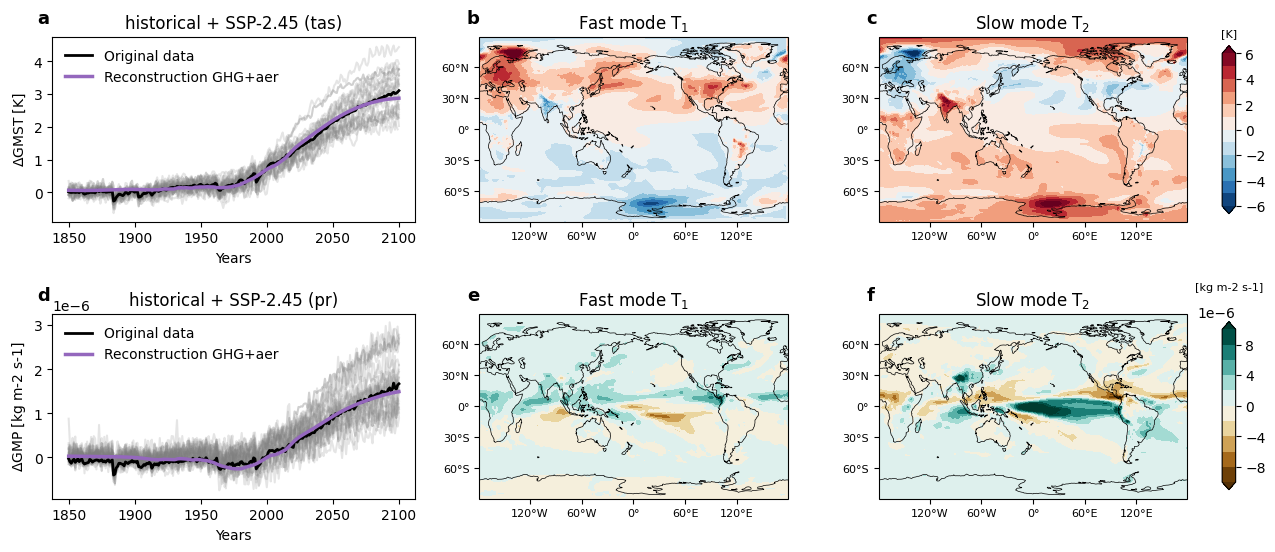

In [33]:
levels = [np.arange(-6,6.1,1), np.arange(-1e-5,1.1e-5,0.2e-5)]
units = ["[K]","[kg m-2 s-1]"]
titles = ["$\Delta$GMST [K]", "$\Delta$GMP [kg m-2 s-1]"]
labels = (["a","b","c"],
          ["d","e","f"])
cmaps = ["RdBu_r","BrBG"]

fig = plt.figure(figsize=(15,6))
gs = GridSpec(2, 3, figure=fig)

for nv,var in enumerate(flds):

    sub = fig.add_subplot(gs[nv, 0])
    sub.set_title("historical + SSP-2.45 ("+var+")")
    sub.set_xlabel("Years")
    sub.set_ylabel(titles[nv])
    #sub.set_xlim(0,100)
    #sub.set_ylim(0,8)
    for nm,mname in enumerate(models):
        sub.plot(np.arange(1850,2101),global_mean(CMIP_aer_pattern_dict[mname].dacanom[var][CMIP_aer_pattern_dict[mname].exp_list.index('sulxanom'), :251, :, :]) - np.nanmean(global_mean(CMIP_aer_pattern_dict[mname].dacanom[var][CMIP_aer_pattern_dict[mname].exp_list.index('sulxanom'), 0:50, :, :])), color="gray", alpha=0.2)
    sub.plot(np.arange(1850,2101),np.nanmean(CMIP_aer_gm_response_sulxanom[nv,:,:],0), color="black", lw=2, label="Original data")
    #sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_ghgonly[nv,:,:],0), color="tab:orange", lw=2.5, label="Reconstruction GHGonly",linestyle='--')
    sub.plot(np.arange(1850,2101), np.nanmean(CMIP_aer_gm_response_recon_sulxanom[nv,:,:],0), color="tab:purple", lw=2.5, label="Reconstruction GHG+aer")
    sub.legend(frameon=False)
    sub.annotate(labels[nv][0], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 1], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    sub.set_title("Fast mode T$_1$")
    cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T1[nv,:,:,:],0), cmap=cmaps[nv], levels=levels[nv], extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.2)
    sub.annotate(labels[nv][1], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 2], projection=ccrs.PlateCarree(central_longitude=180))
    sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
    sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
    sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
    sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
    sub.coastlines(lw=0.5)
    sub.set_title("Slow mode T$_2$")
    cont = sub.contourf(common_lons, common_lats, np.nanmean(common_grid_aer_data_T2[nv,:,:,:],0), cmap=cmaps[nv], levels=levels[nv], extend="both", transform=cart.crs.PlateCarree())
    sub.set_aspect(1.2)
    sub.annotate(labels[nv][2], xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

    # external colorbar
    if var == "tas":
        cbar = fig.add_axes([0.905, 0.585, 0.009, 0.28])
    if var == "pr":
        cbar = fig.add_axes([0.905, 0.125, 0.009, 0.28])
    fig.colorbar(cont, cax=cbar,orientation='vertical')
    cbar.set_title(units[nv], size=8, pad=12, ha="center")

fig.subplots_adjust(wspace=0.1, hspace=0.5)
plt.savefig(os.path.join(figdir, "CMIP_aer_pattern_composite.pdf"), bbox_inches='tight')

In [34]:
%%capture

# also capture the spatial response of the last 20 years (2080--2100)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

patterns_aer_ssp_common_grid=np.zeros([len(models),len(scenarios),len(flds), len(common_lats), len(common_lons)])

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):

                native_data = np.nanmean(CMIP_aer_pattern_dict[mname].predict_from_combined_experiment(
                        em_data_fwd[nsc], conc_data_fwd[nsc], [var]
                )[var].values[-20:,:,:],0)
                native_lons = CMIP_aer_pattern_dict[mname].predict_from_combined_experiment(em_data_fwd[nsc], conc_data_fwd[nsc], [var])[var].lon
                native_lats = CMIP_aer_pattern_dict[mname].predict_from_combined_experiment(em_data_fwd[nsc], conc_data_fwd[nsc], [var])[var].lat
                native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
                # Interpolate
                patterns_aer_ssp_common_grid[nm,nsc,nv,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')

In [35]:
# delete here to make 'space' for aerosol pattern dictionary
del(CMIP_aer_pattern_dict)
del(patterns_ghg)
del(patterns_anomsulf)

# Evaluation of timescale separation

In [36]:
%%capture

timescales=[1,2,3,4,5]
tser1 = np.zeros([len(flds),len(models),len(timescales),100])
tser2 = np.zeros([len(flds),len(models),len(timescales),100])
mae = np.zeros([len(flds),len(models),len(timescales)])
rmse = np.zeros([len(flds),len(models),len(timescales)])
CMIP_ghg_pattern_dict_tscales = {}

for nm,mname in enumerate(models):

    # create GHG modes and spatial pattern
    for nts,ts in enumerate(timescales):

        CMIP_ghg_pattern_dict_tscales = MeteorPatternScaling(
                mname,
                {"tas": ts, "pr": ts},
                lambda key: training_data_dict[mname][key],
                from_file=False,
                exp_list=["base", "co2x4"],
            )

        # calculate goodness of the fit vs. orginal data
        for nv,var in enumerate(flds):
            tser1[nv,nm,nts,:] = global_mean(CMIP_ghg_pattern_dict_tscales.dacanom[var][CMIP_ghg_pattern_dict_tscales.exp_list.index('co2x4'), :100, :, :])
            tser2[nv,nm,nts,:] = global_mean(recon(CMIP_ghg_pattern_dict_tscales.pattern_dict['co2x4'][var]['pattern_full']))
            mae[nv,nm,nts] = np.abs(tser1[nv,nm,nts,:]-tser2[nv,nm,nts,:]).mean()
            rmse[nv,nm,nts] = np.sqrt(np.mean((tser1[nv,nm,nts,:]-tser2[nv,nm,nts,:])**2))


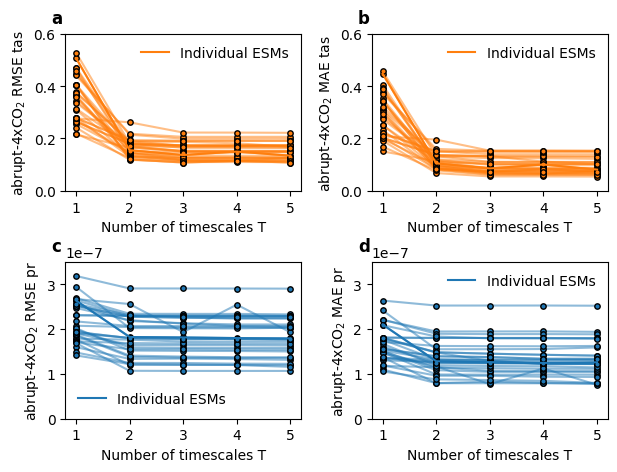

In [37]:
ylims_min=[0,0e-7]
ylims_max=[0.6,3.5e-7]
colors=["tab:orange","tab:blue"]
labels = (["a","b"],
          ["c","d"])

fig = plt.figure(figsize=(7,5))
gs = GridSpec(2, 2, figure=fig)

for nv,var in enumerate(flds):

    sub = fig.add_subplot(gs[nv, 0])
    sub.set_ylabel('abrupt-4xCO$_2$ RMSE '+var)
    sub.set_xlabel('Number of timescales T')
    sub.set_ylim(ylims_min[nv],ylims_max[nv])
    sub.set_xticks([0,1,2,3,4])
    sub.set_xticklabels([1,2,3,4,5])
    for m in np.arange(0,rmse.shape[1]):
        if m == 0: sub.plot(rmse[nv,m,:], color=colors[nv], label="Individual ESMs")
        sub.plot(rmse[nv,m,:], color=colors[nv],alpha=0.5,zorder=0)
        sub.scatter(np.arange(0,5), rmse[nv,m,:], color=colors[nv], s=15, edgecolor="black")
    sub.legend(frameon=False)
    sub.annotate(labels[nv][0], xy=(-0.06, 1.1), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

    sub = fig.add_subplot(gs[nv, 1])
    sub.set_xlabel('Number of timescales T')
    sub.set_ylabel('abrupt-4xCO$_2$ MAE '+var)
    sub.set_ylim(ylims_min[nv],ylims_max[nv])
    sub.set_xticks([0,1,2,3,4])
    sub.set_xticklabels([1,2,3,4,5])
    for m in np.arange(0,mae.shape[1]):
        if m == 0: sub.plot(mae[nv,m,:], color=colors[nv], label="Individual ESMs")
        sub.plot(mae[nv,m,:], color=colors[nv],alpha=0.5,zorder=0)
        sub.scatter(np.arange(0,5), mae[nv,m,:], color=colors[nv], s=15, edgecolor="black")
    sub.legend(frameon=False)
    sub.annotate(labels[nv][1], xy=(-0.06, 1.1), xycoords='axes fraction', fontsize=12, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.3, hspace=0.45)
plt.savefig(os.path.join(figdir, "fit_timescale_evaluation.pdf"), bbox_inches='tight')

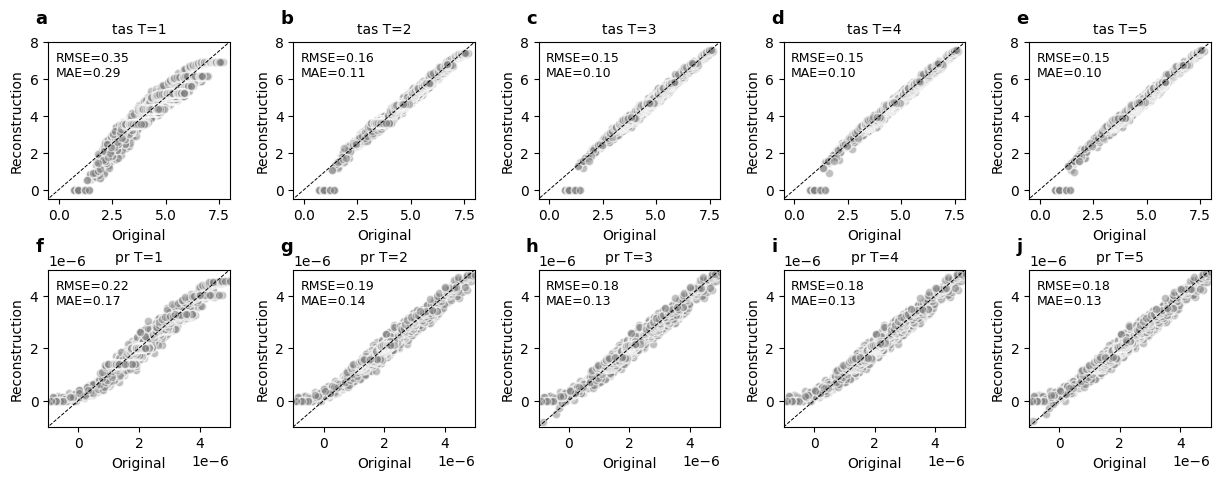

In [38]:
lims_min=[-0.5,-1e-6]
lims_max=[8,5e-6]
labels = (["a","b","c","d","e"],
          ["f","g","h","i","j"])

fig = plt.figure(figsize=(15,5))
gs = GridSpec(2, 5, figure=fig)

for nv,var in enumerate(flds):
    for ntsc,tsc in enumerate(timescales):
        sub = fig.add_subplot(gs[nv, ntsc])
        sub.set_title(var+" T="+str(tsc), size=10)
        sub.set_xlabel("Original")
        sub.set_ylabel("Reconstruction")
        sub.set_ylim(lims_min[nv],lims_max[nv])
        sub.set_xlim(lims_min[nv],lims_max[nv])
        #sub.set_xticks([0,1,2,3,4])
        #sub.set_xticklabels([1,2,3,4,5])
        for m in np.arange(0,tser1.shape[1]):
            sub.scatter(tser1[nv,m,ntsc,:], tser2[nv,m,ntsc,:], color="gray", alpha=0.5, edgecolor="white")
        sub.plot([-100,100],[-100,100], color="black", lw=0.7, linestyle="--")
        sub.annotate(labels[nv][ntsc], xy=(-0.07, 1.15), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
        if var=='pr':
            sub.annotate("RMSE="+"{:.2f}".format(np.nanmean(rmse[nv,:,ntsc]*1e6)), xy=(0.04, 0.9), xycoords='axes fraction', fontsize=9, ha='left', va='center')
            sub.annotate("MAE="+"{:.2f}".format(np.nanmean(mae[nv,:,ntsc]*1e6)), xy=(0.04, 0.8), xycoords='axes fraction', fontsize=9, ha='left', va='center')
        else:
            sub.annotate("RMSE="+"{:.2f}".format(np.nanmean(rmse[nv,:,ntsc])), xy=(0.04, 0.9), xycoords='axes fraction', fontsize=9, ha='left', va='center')
            sub.annotate("MAE="+"{:.2f}".format(np.nanmean(mae[nv,:,ntsc])), xy=(0.04, 0.8), xycoords='axes fraction', fontsize=9, ha='left', va='center')
        
fig.subplots_adjust(wspace=0.35, hspace=0.45)
plt.savefig(os.path.join(figdir, "fit_timescale_evaluation_scatter.pdf"), bbox_inches='tight')

# Application to new scenarios

### SSP534-over

In [39]:
%%capture
# Only for SSP534-over
# make sure that all data for the models from the SSP534-over list are available in training_data_dict (i.e. in cache)

target_model_grid = 'ACCESS-CM2'
common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)
patterns_aer_ssp534_common_grid=np.zeros([len(models_ssp534),1,len(flds), len(common_lats), len(common_lons)])

patterns_ghg_ssp534={}
patterns_aer_ssp534={}

for nm,mname in enumerate(models_ssp534):
    patterns_ghg_ssp534[mname]={}
    patterns_aer_ssp534[mname]={}

    # create GHG modes and spatial pattern
    CMIP_ghg_pattern={}
    CMIP_ghg_pattern = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data_dict_ssp534[mname][key],
            from_file=False,
            exp_list=["base", "co2x4"],
        )

    # create GHG modes and spatial pattern
    CMIP_aer_pattern={}
    CMIP_aer_pattern = MeteorPatternScaling(
            mname,
            {"tas": 2, "pr": 2},
            lambda key: training_data_dict_ssp534[mname][key],
            from_file=False,
            exp_list=["base", "co2x4", "sulxanom"],
        )

    for nsc,sc in enumerate(['ssp534-over']):
        patterns_ghg_ssp534[mname][sc] = CMIP_ghg_pattern.predict_from_combined_experiment(
                em_data_ssp534[nsc], conc_data_ssp534[nsc], ["pr", "tas"]
        )
        patterns_aer_ssp534[mname][sc] = CMIP_aer_pattern.predict_from_combined_experiment(
                em_data_ssp534[nsc], conc_data_ssp534[nsc], ["pr", "tas"]
        )

        # Interpolation for spatial pattern evaluation plots
        for nv,var in enumerate(flds):
            native_data = np.nanmean(CMIP_aer_pattern.predict_from_combined_experiment(
                    em_data_ssp534[nsc], conc_data_ssp534[nsc], [var]
            )[var].values[-20:,:,:],0)
            native_lons = CMIP_aer_pattern.predict_from_combined_experiment(em_data_ssp534[nsc], conc_data_ssp534[nsc], [var])[var].lon
            native_lats = CMIP_aer_pattern.predict_from_combined_experiment(em_data_ssp534[nsc], conc_data_ssp534[nsc], [var])[var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            patterns_aer_ssp534_common_grid[nm,nsc,nv,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                        np.array(native_data).flatten(), 
                                        (common_lon_grid, common_lat_grid), method='cubic')

In [51]:
### global mean timeseries (standard SSPs)
td_ssp = np.zeros([len(flds),len(scenarios),len(models),251]) * np.nan

for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            dur = global_mean(training_data_dict[mname][sc]['tas']).values[0,:].shape[0]
            if dur > 251: dur = 251
            else: dur = dur
            #td_ssp[nv,nsc,nm,0:dur] = global_mean(training_data_dict[mname][sc][var]).values[0,0:dur]-np.nanmean(global_mean(training_data_dict[mname]["base"][var]).values[-500:])     # subtracting piC
            td_ssp[nv,nsc,nm,0:dur] = global_mean(training_data_dict[mname][sc][var]).values[0,0:dur]-np.nanmean(global_mean(training_data_dict[mname][sc][var]).values[0,0:50])     # subtracting first 50 year-average
patterns_ghg_ssp_gm = patterns_ghg_ssp[:,:,:,100:]
patterns_aer_ssp_gm = patterns_aer_ssp[:,:,:,100:]

### global mean timeseries (SSP534-over)
td_ssp534 = np.zeros([len(flds),len(models_ssp534),251]) * np.nan
patterns_ghg_ssp534_gm = np.zeros([len(flds),len(models_ssp534),251]) * np.nan
patterns_aer_ssp534_gm = np.zeros([len(flds),len(models_ssp534),251]) * np.nan
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        #td_ssp534[nv,nm,:] = global_mean(training_data_dict_ssp534[mname]['ssp534-over'][var]).values[0,:251]-np.nanmean(global_mean(training_data_dict_ssp534[mname]["base"][var]).values[-100:])
        patterns_ghg_ssp534_gm[nv,nm,:] = global_mean(patterns_ghg_ssp534[mname]['ssp534-over'][var]).values[100:]
        patterns_aer_ssp534_gm[nv,nm,:] = global_mean(patterns_aer_ssp534[mname]['ssp534-over'][var]).values[100:]


### Plotting

single model total response

In [41]:
%%capture

var_idx = 0  # tas
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]
midx534 = [i for i, element in enumerate(models) if element in models_ssp534]  # get indices of ssp534 models in all model array

fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 5, figure=fig)

c534 = -1
for nm,mname in enumerate(models):
    # row-fig 1--4
    for sci in np.arange(0,4):
        sub = fig.add_subplot(gs[nm, sci])
        if nm == 0: sub.set_title(titles[sci])
        if sci == 0: sub.set_ylabel("$\Delta$GMST [K]")
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,sci,nm,:], color="lightgray", label="Original")
        sub.plot(np.arange(1850,2101), patterns_ghg_ssp_gm[nm,sci,var_idx,:], color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), patterns_aer_ssp_gm[nm,sci,var_idx,:], color="tab:purple", label="GHG+aer", lw=1.5)
        if sci == 0: sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")
        if sci == 0 and nm == 0: sub.legend(frameon=False, loc="upper left",bbox_to_anchor=[0,0.9], prop={'size': 9})
    # row-fig 5
    sub = fig.add_subplot(gs[nm, 4])
    if nm in midx534:
        c534 = c534+1
        if c534 == 0: sub.set_title('SSP-5.34-over')
        #--- CMIP6 data ---
        sub.plot(np.arange(1850,2101), patterns_ghg_ssp534_gm[var_idx,c534,:], color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), patterns_aer_ssp534_gm[var_idx,c534,:], color="tab:purple", label="GHG+aer", lw=1.5)
    else:
        sub.axis('off')

fig.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_tas_single.pdf"), bbox_inches='tight')


In [42]:
%%capture

var_idx = 1  # pr
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]
midx534 = [i for i, element in enumerate(models) if element in models_ssp534]  # get indices of ssp534 models in all model array

fig = plt.figure(figsize=(15,len(models)*2.5))
gs = GridSpec(len(models), 5, figure=fig)

c534 = -1
for nm,mname in enumerate(models):
    # row-fig 1--4
    for sci in np.arange(0,4):
        sub = fig.add_subplot(gs[nm, sci])
        if nm == 0: sub.set_title(titles[sci])
        if sci == 0: sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,sci,nm,:], color="lightgray", label="Original")
        sub.plot(np.arange(1850,2101), patterns_ghg_ssp_gm[nm,sci,var_idx,:], color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), patterns_aer_ssp_gm[nm,sci,var_idx,:], color="tab:purple", label="GHG+aer", lw=1.5)
        if sci == 0: sub.annotate(mname, xy=(0.02, 0.92), xycoords='axes fraction', fontsize=10, ha='left', va='center', weight="bold")
        if sci == 0 and nm == 0: sub.legend(frameon=False, loc="upper left",bbox_to_anchor=[0,0.9], prop={'size': 9})
    # row-fig 5
    sub = fig.add_subplot(gs[nm, 4])
    if nm in midx534:
        c534 = c534+1
        if c534 == 0: sub.set_title('SSP-5.34-over')
        #--- CMIP6 data ---
        sub.plot(np.arange(1850,2101), patterns_ghg_ssp534_gm[var_idx,c534,:], color="tab:orange", label="GHG only", lw=1.5, linestyle=':')
        sub.plot(np.arange(1850,2101), patterns_aer_ssp534_gm[var_idx,c534,:], color="tab:purple", label="GHG+aer", lw=1.5)
    else:
        sub.axis('off')

fig.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_pr_single.pdf"), bbox_inches='tight')


Multi-model average total response 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/2406368345.py:58: RuntimeWarning: Mean of empty slice
  sub.scatter(2,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/2406368345.py:59: RuntimeWarning: Mean of empty slice
  sub.plot([2,2],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0)], color="tab:purple",

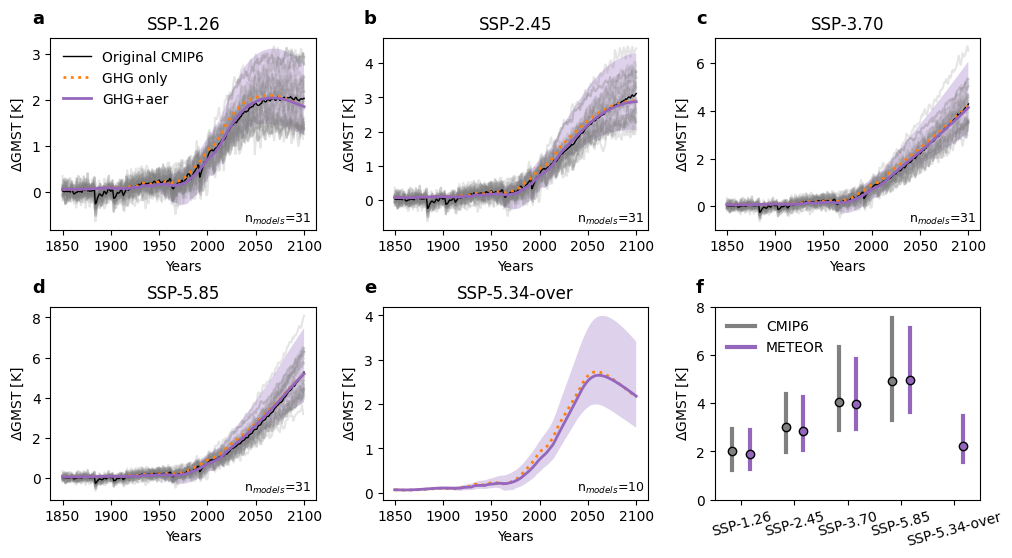

In [52]:
var_idx = 0

fig = plt.figure(figsize=(12,6))

gs = GridSpec(2, 3, figure=fig)

gsx = [0,0,0,1]
gsy = [0,1,2,0]
sublabel = ['a','b','c','d']
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]

# subfigures 1--4
for sci in np.arange(0,4):
    sub = fig.add_subplot(gs[gsx[sci], gsy[sci]])
    sub.set_title(titles[sci])
    sub.set_xlabel("Years")
    sub.set_ylabel("$\Delta$GMST [K]")
    #sub.set_ylim(-1,3.5)
    for nm,mname in enumerate(models):
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,sci,nm,:], color="gray", alpha=0.2)
    if sci == 0:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,sci,:,:],0), color="black", label="Original CMIP6", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_ghg_ssp_gm[:,sci,var_idx,:],0), color="tab:orange", label="GHG only", lw=2, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_aer_ssp_gm[:,sci,var_idx,:],0), color="tab:purple", label="GHG+aer", lw=2)
    else:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,sci,:,:],0), color="black", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_ghg_ssp_gm[:,sci,var_idx,:],0), color="tab:orange", lw=2, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_aer_ssp_gm[:,sci,var_idx,:],0), color="tab:purple", lw=2)
    sub.fill_between(np.arange(1850,2101), np.nanmin(patterns_aer_ssp_gm[:,sci,var_idx,:],0), np.nanmax(patterns_aer_ssp_gm[:,sci,var_idx,:],0), color="tab:purple", alpha=0.3, edgecolor="none")
    sub.legend(frameon=False)
    sub.annotate(sublabel[sci], xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('n$_{models}$='+str(len(models)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 5
sub = fig.add_subplot(gs[1, 1])
sub.set_title("SSP-5.34-over")
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMST [K]")
#for nm,mname in enumerate(models_ssp534):
    #sub.plot(np.arange(1850,2101), global_mean(training_data_dict_ssp534[mname]['ssp534-over']['tas']).values[0,:251]-np.nanmean(global_mean(training_data_dict_ssp534[mname]["base"]['tas']).values[-100:]), color="gray", alpha=0.2)
#sub.plot(np.arange(1850,2101), np.nanmean(td_ssp_534[:,:],0), color="black", label="Original data", lw=1)
sub.plot(np.arange(1850,2101), np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,:],0), color="tab:orange", label="GHG only", lw=2, linestyle=':')
sub.plot(np.arange(1850,2101), np.nanmean(patterns_aer_ssp534_gm[var_idx,:,:],0), color="tab:purple", label="GHG+aer", lw=2)
sub.fill_between(np.arange(1850,2101), np.nanmin(patterns_aer_ssp534_gm[var_idx,:,:],0), np.nanmax(patterns_aer_ssp534_gm[var_idx,:,:],0), color="tab:purple", alpha=0.3, edgecolor="none")
sub.annotate('e', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('n$_{models}$='+str(len(models_ssp534)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 6
sub = fig.add_subplot(gs[1, 2])
sub.set_xlim(0,15)
sub.set_ylim(0,8)
sub.set_xticks([1.5,4.5,7.5,10.5,13.5])
sub.set_xticklabels(['SSP-1.26','SSP-2.45','SSP-3.70','SSP-5.85','SSP-5.34-over'], rotation=15)
sub.set_ylabel("$\Delta$GMST [K]")

sub.scatter(1,np.nanmean(np.nanmean(td_ssp[var_idx,0,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([1,1],[np.nanmin(np.nanmean(td_ssp[var_idx,0,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,0,:,-10:],1),0)], color="gray", lw=3, zorder=0, label="CMIP6")
sub.scatter(2,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([2,2],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0, label="METEOR")
sub.legend(frameon=False)

sub.scatter(4,np.nanmean(np.nanmean(td_ssp[var_idx,1,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([4,4],[np.nanmin(np.nanmean(td_ssp[var_idx,1,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,1,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(5,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,1,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([5,5],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,1,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,1,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0)

sub.scatter(7,np.nanmean(np.nanmean(td_ssp[var_idx,2,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([7,7],[np.nanmin(np.nanmean(td_ssp[var_idx,2,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,2,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(8,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,2,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([8,8],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,2,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,2,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0)

sub.scatter(10,np.nanmean(np.nanmean(td_ssp[var_idx,3,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([10,10],[np.nanmin(np.nanmean(td_ssp[var_idx,3,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,3,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(11,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,3,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([11,11],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,3,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,3,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0)


sub.scatter(14,np.nanmean(np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([14,14],[np.nanmin(np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,-10:],1),0),np.nanmax(np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,-10:],1),0)], color="tab:purple", lw=3, zorder=0)
sub.annotate('f', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.25, hspace=0.4)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_tas.pdf"), bbox_inches='tight')


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/264835943.py:57: RuntimeWarning: Mean of empty slice
  sub.scatter(2,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/264835943.py:58: RuntimeWarning: Mean of empty slice
  sub.plot([2,2],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0)], color="tab:purple", l

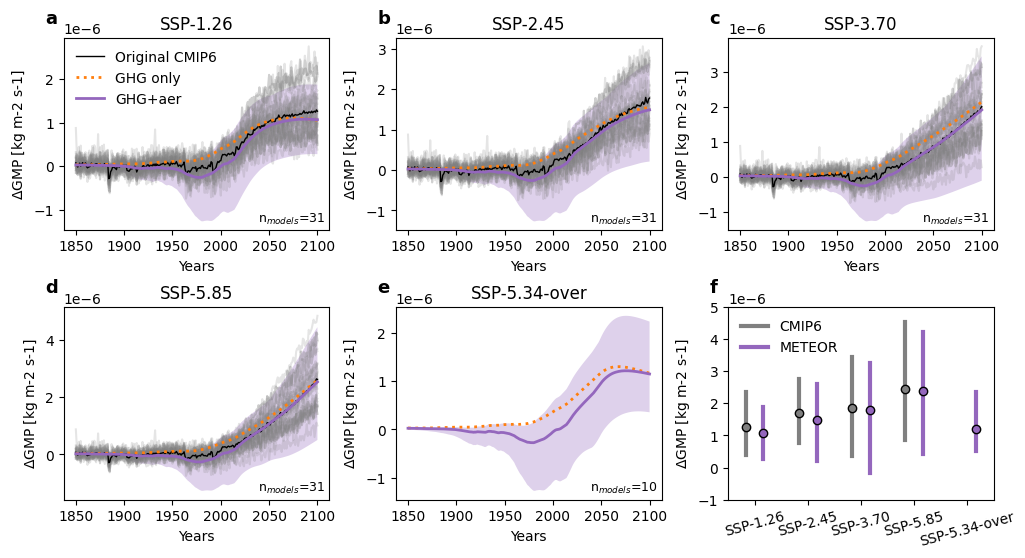

In [53]:
var_idx = 1

fig = plt.figure(figsize=(12,6))

gs = GridSpec(2, 3, figure=fig)

gsx = [0,0,0,1]
gsy = [0,1,2,0]
sublabel = ['a','b','c','d']
titles = ["SSP-1.26","SSP-2.45","SSP-3.70","SSP-5.85"]

# subfigures 1--4
for sci in np.arange(0,4):
    sub = fig.add_subplot(gs[gsx[sci], gsy[sci]])
    sub.set_title(titles[sci])
    sub.set_xlabel("Years")
    sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
    for nm,mname in enumerate(models):
        sub.plot(np.arange(1850,2101), td_ssp[var_idx,sci,nm,:], color="gray", alpha=0.2)
    if sci == 0:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,sci,:,:],0), color="black", label="Original CMIP6", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_ghg_ssp_gm[:,sci,var_idx,:],0), color="tab:orange", label="GHG only", lw=2, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_aer_ssp_gm[:,sci,var_idx,:],0), color="tab:purple", label="GHG+aer", lw=2)
    else:
        sub.plot(np.arange(1850,2101), np.nanmean(td_ssp[var_idx,sci,:,:],0), color="black", lw=1)
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_ghg_ssp_gm[:,sci,var_idx,:],0), color="tab:orange", lw=2, linestyle=':')
        sub.plot(np.arange(1850,2101), np.nanmean(patterns_aer_ssp_gm[:,sci,var_idx,:],0), color="tab:purple", lw=2)
    sub.fill_between(np.arange(1850,2101), np.nanmin(patterns_aer_ssp_gm[:,sci,var_idx,:],0), np.nanmax(patterns_aer_ssp_gm[:,sci,var_idx,:],0), color="tab:purple", alpha=0.3, edgecolor="none")
    sub.legend(frameon=False)
    sub.annotate(sublabel[sci], xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
    sub.annotate('n$_{models}$='+str(len(models)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 5
sub = fig.add_subplot(gs[1, 1])
sub.set_title("SSP-5.34-over")
sub.set_xlabel("Years")
sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")
#for nm,mname in enumerate(models_ssp534):
    #sub.plot(np.arange(1850,2101), global_mean(training_data_dict_ssp534[mname]['ssp534-over']['tas']).values[0,:251]-np.nanmean(global_mean(training_data_dict_ssp534[mname]["base"]['tas']).values[-100:]), color="gray", alpha=0.2)
#sub.plot(np.arange(1850,2101), np.nanmean(td_ssp_534[:,:],0), color="black", label="Original data", lw=1)
sub.plot(np.arange(1850,2101), np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,:],0), color="tab:orange", label="GHG only", lw=2, linestyle=':')
sub.plot(np.arange(1850,2101), np.nanmean(patterns_aer_ssp534_gm[var_idx,:,:],0), color="tab:purple", label="GHG+aer", lw=2)
sub.fill_between(np.arange(1850,2101), np.nanmin(patterns_aer_ssp534_gm[var_idx,:,:],0), np.nanmax(patterns_aer_ssp534_gm[var_idx,:,:],0), color="tab:purple", alpha=0.3, edgecolor="none")
sub.annotate('e', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('n$_{models}$='+str(len(models_ssp534)), xy=(0.73, 0.06), xycoords='axes fraction', fontsize=9, ha='left', va='center')

# subfigure 6
sub = fig.add_subplot(gs[1, 2])
sub.set_xlim(0,15)
sub.set_ylim(-1e-6,5e-6)
sub.set_xticks([1.5,4.5,7.5,10.5,13.5])
sub.set_xticklabels(['SSP-1.26','SSP-2.45','SSP-3.70','SSP-5.85','SSP-5.34-over'], rotation=15)
sub.set_ylabel("$\Delta$GMP [kg m-2 s-1]")

sub.scatter(1,np.nanmean(np.nanmean(td_ssp[var_idx,0,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([1,1],[np.nanmin(np.nanmean(td_ssp[var_idx,0,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,0,:,-10:],1),0)], color="gray", lw=3, zorder=0, label="CMIP6")
sub.scatter(2,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([2,2],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,0,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0, label="METEOR")
sub.legend(frameon=False)

sub.scatter(4,np.nanmean(np.nanmean(td_ssp[var_idx,1,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([4,4],[np.nanmin(np.nanmean(td_ssp[var_idx,1,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,1,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(5,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,1,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([5,5],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,1,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,1,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0)

sub.scatter(7,np.nanmean(np.nanmean(td_ssp[var_idx,2,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([7,7],[np.nanmin(np.nanmean(td_ssp[var_idx,2,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,2,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(8,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,2,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([8,8],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,2,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,2,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0)

sub.scatter(10,np.nanmean(np.nanmean(td_ssp[var_idx,3,:,-10:],1),0), color="gray", edgecolor="black")
sub.plot([10,10],[np.nanmin(np.nanmean(td_ssp[var_idx,3,:,-10:],1),0),np.nanmax(np.nanmean(td_ssp[var_idx,3,:,-10:],1),0)], color="gray", lw=3, zorder=0)
sub.scatter(11,np.nanmean(np.nanmean(patterns_aer_ssp_gm[:,3,var_idx,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([11,11],[np.nanmin(np.nanmean(patterns_aer_ssp_gm[:,3,var_idx,-10:],1),0),np.nanmax(np.nanmean(patterns_aer_ssp_gm[:,3,var_idx,-10:],1),0)], color="tab:purple", lw=3, zorder=0)


sub.scatter(14,np.nanmean(np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,-10:],1),0), color="tab:purple", edgecolor="black")
sub.plot([14,14],[np.nanmin(np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,-10:],1),0),np.nanmax(np.nanmean(patterns_ghg_ssp534_gm[var_idx,:,-10:],1),0)], color="tab:purple", lw=3, zorder=0)
sub.annotate('f', xy=(-0.07, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.25, hspace=0.4)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_pr.pdf"), bbox_inches='tight')


### Spatial evaluation

Standard SSPs

In [45]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp_common_grid = np.zeros([len(flds),len(scenarios),len(models),len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models):
        for nsc,sc in enumerate(scenarios):
            native_data = np.nanmean(training_data_dict[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100
            native_lons = training_data_dict[mname][sc][var].lon
            native_lats = training_data_dict[mname][sc][var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            td_ssp_common_grid[nv,nsc,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/1140181753.py:16: RuntimeWarning: Mean of empty slice
  native_data = np.nanmean(training_data_dict[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100


SSP534-over

In [46]:
# interpolate gridded data to common grid
# (common-grid data for METEOR reconstruction spatial fields comes from above)

target_model_grid = 'ACCESS-CM2'

common_lons = training_data_dict[target_model_grid]['base']['tas'].lon
common_lats = training_data_dict[target_model_grid]['base']['tas'].lat
common_lon_grid, common_lat_grid = np.meshgrid(common_lons, common_lats)

td_ssp534_common_grid = np.zeros([len(flds),1,len(models_ssp534),len(common_lats),len(common_lons)]) * np.nan

# Interpolate to native grid and data
for nv,var in enumerate(flds):
    for nm,mname in enumerate(models_ssp534):
        for nsc,sc in enumerate(['ssp534-over']):
            native_data = np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100
            native_lons = training_data_dict_ssp534[mname][sc][var].lon
            native_lats = training_data_dict_ssp534[mname][sc][var].lat
            native_lons_grid, native_lats_grid = np.meshgrid(native_lons, native_lats)
            # Interpolate
            td_ssp534_common_grid[nv,nsc,nm,:,:] = griddata(np.column_stack((native_lons_grid.flatten(), native_lats_grid.flatten())), 
                                            np.array(native_data).flatten(), 
                                            (common_lon_grid, common_lat_grid), method='cubic')


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/1780264212.py:16: RuntimeWarning: Mean of empty slice
  native_data = np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,-20:,:,:],0)-np.nanmean(training_data_dict_ssp534[mname][sc][var].values[0,0:50],0)   # subtracting first 50 year-average from 2080--2100


/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/3983697078.py:84: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/3983697078.py:108: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())


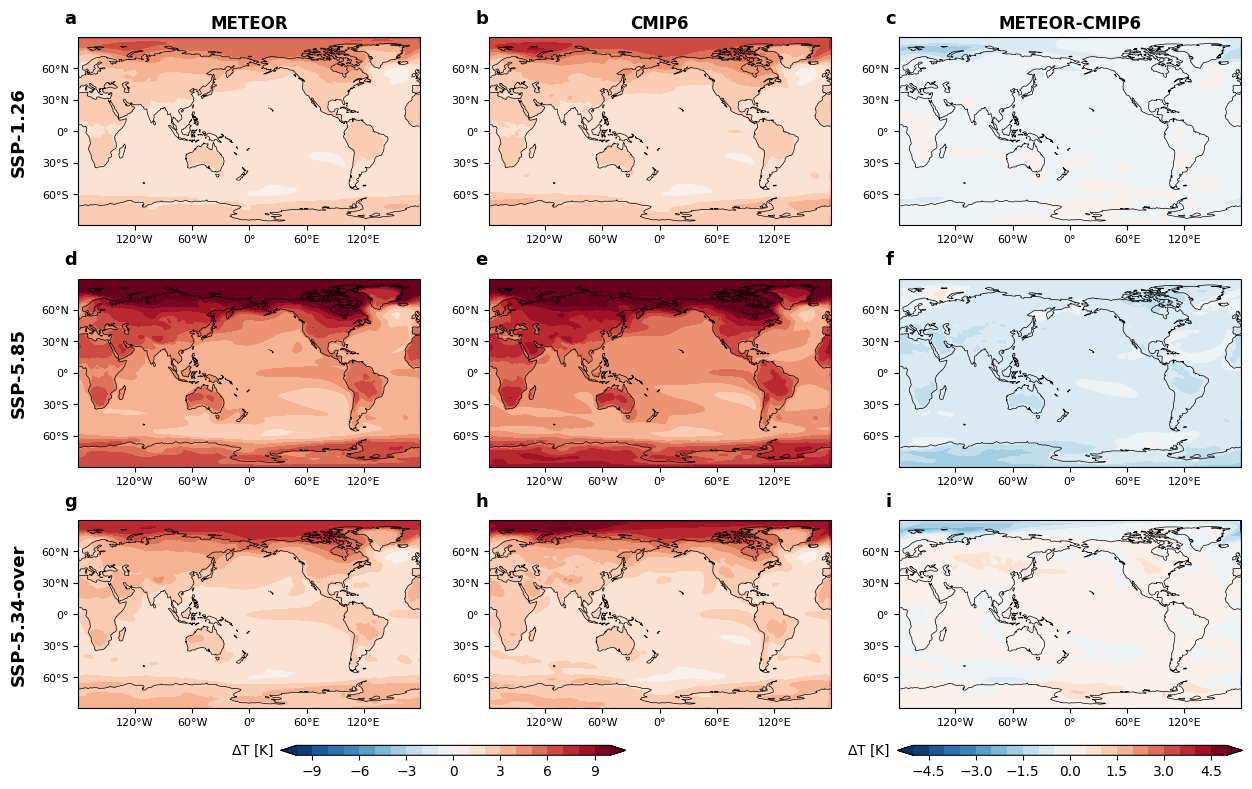

In [47]:
var_idx = 0
levels = np.arange(-10,10.1,1)
cmap="RdBu_r"

fig = plt.figure(figsize=(15,9))
gs = GridSpec(3, 3, figure=fig)

# row 1
sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
#cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
#cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
sub.set_aspect(1.1)
sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)  
sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR-CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 2
sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1) 
sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 3
sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.241,0.071,"$\Delta$T [K]",ha="center")
sub.set_aspect(1.1)
sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.34-over', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels/2, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.652,0.071,"$\Delta$T [K]",ha="center")
sub.set_aspect(1.1)
sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.2, hspace=0.15)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_spatial_tas.pdf"), bbox_inches='tight')

/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/793677601.py:84: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
/var/folders/mt/vkb75n9d7kx45p7qhp1fc52r0000gn/T/ipykernel_57758/793677601.py:108: RuntimeWarning: Mean of empty slice
  cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())


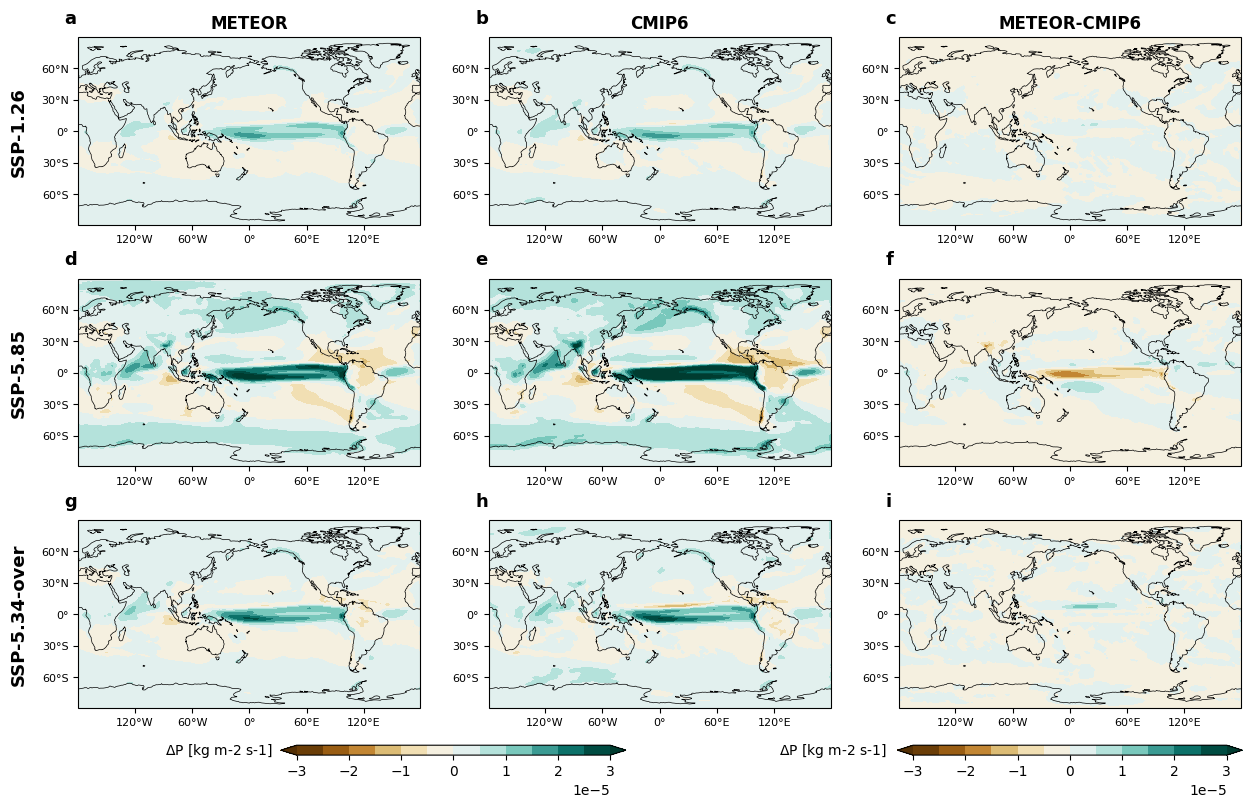

In [48]:
var_idx = 1
levels = np.arange(-3e-5,3.1e-5,0.5e-5)
cmap="BrBG"

fig = plt.figure(figsize=(15,9))
gs = GridSpec(3, 3, figure=fig)

# row 1
sub = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
#cbar_ax = fig.add_axes([0.26, 0.63, 0.23, 0.011])
#cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
sub.set_aspect(1.1)
sub.annotate('a', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-1.26', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)  
sub.annotate('b', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[0, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_title('METEOR-CMIP6', weight="bold")
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('c', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 2
sub = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('d', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.85', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1) 
sub.annotate('e', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp_common_grid[:,3,var_idx,:,:],0)-np.nanmean(td_ssp_common_grid[var_idx,3,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('f', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

#row 3
sub = fig.add_subplot(gs[2, 0], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.26, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.219,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
sub.set_aspect(1.1)
sub.annotate('g', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")
sub.annotate('SSP-5.34-over', xy=(-0.2, 0.5), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold", rotation=90)

sub = fig.add_subplot(gs[2, 1], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
sub.set_aspect(1.1)
sub.annotate('h', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

sub = fig.add_subplot(gs[2, 2], projection=ccrs.PlateCarree(central_longitude=180))
sub.set_xticks(np.arange(60, 301, 60), crs=ccrs.PlateCarree())
sub.set_xticklabels(["120°W","60°W","0°","60°E","120°E"], size=8)
sub.set_yticks(np.arange(-60, 61, 30), crs=ccrs.PlateCarree())
sub.set_yticklabels(["60°S","30°S","0°","30°N","60°N"], size=8)
sub.coastlines(lw=0.5)
cont = sub.contourf(common_lons, common_lats, np.nanmean(patterns_aer_ssp534_common_grid[:,0,var_idx,:,:],0)-np.nanmean(td_ssp534_common_grid[var_idx,0,:,:,:],0), cmap=cmap, levels=levels, extend="both", transform=cart.crs.PlateCarree())
cbar_ax = fig.add_axes([0.671, 0.07, 0.23, 0.011])
cb = fig.colorbar(cont, cax=cbar_ax,orientation='horizontal')
fig.text(0.628,0.071,"$\Delta$P [kg m-2 s-1]",ha="center")
sub.set_aspect(1.1)
sub.annotate('i', xy=(-0.04, 1.1), xycoords='axes fraction', fontsize=13, ha='left', va='center', weight="bold")

fig.subplots_adjust(wspace=0.2, hspace=0.15)
plt.savefig(os.path.join(figdir, "CMIP_recon_SSPs_spatial_pr.pdf"), bbox_inches='tight')

Pattern correlation and RMSE

In [49]:
%%capture

Pcorr = np.zeros([2,5]) * np.nan
Prmse = np.zeros([2,5]) * np.nan

for nv,var in enumerate(flds):
    for nsc,sc in enumerate(scenarios):
        if nsc == 0:
            # Standard SSPs
            array1 = np.nanmean(patterns_aer_ssp_common_grid[:,nsc,nv,:,:],0).ravel()
            array2 = np.nanmean(td_ssp_common_grid[nv,nsc,:,:,:],0).ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc] = correlation
            Prmse[nv,nsc] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE
            # SSP534 (and put in higher index)
            array1 = np.nanmean(patterns_aer_ssp534_common_grid[:,nsc,nv,:,:],0).ravel()
            array2 = np.nanmean(td_ssp534_common_grid[nv,nsc,:,:,:],0).ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc+4] = correlation
            Prmse[nv,nsc+4] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE
        else:
            # Continue with standard SSPs
            array1 = np.nanmean(patterns_aer_ssp_common_grid[:,nsc,nv,:,:],0).ravel()
            array2 = np.nanmean(td_ssp_common_grid[nv,nsc,:,:,:],0).ravel()
            valid_mask = ~np.isnan(array1) & ~np.isnan(array2)     # handle NaN values
            correlation, _ = pearsonr(array1[valid_mask], array2[valid_mask])       # Pearson correlation
            Pcorr[nv,nsc] = correlation
            Prmse[nv,nsc] = np.sqrt(np.mean((array1[valid_mask] - array2[valid_mask]) ** 2))   # RMSE


In [50]:
print('tas')
print('Pearson:', Pcorr[0,:])
print('RMSE:', Prmse[0,:])
print('pr')
print('Pearson:', Pcorr[1,:])
print('RMSE:', Prmse[1,:]*1e7)


tas
Pearson: [0.99253286 0.99795749 0.99753065 0.99593144 0.96924189]
RMSE: [0.31076486 0.13281866 0.20595488 0.82533401 0.54925353]
pr
Pearson: [0.95844891 0.98504949 0.98650334 0.97269857 0.94710129]
RMSE: [ 7.08748237  5.74226429  7.55949526 24.57463349 11.47465011]
